In [94]:
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model

In [95]:
# this is the size of our encoded representations
encoding_dim = 32
# 32 floats -> compression of factor 24.5, assuming the input is 784 floats

# this is our input placeholder
input_img = Input(shape=(784,))
# "encoded" is the encoded representation of the input
encoded = Dense(encoding_dim, activation='relu')(input_img)
# "decoded" is the lossy reconstruction of the input
decoded = Dense(784, activation='sigmoid')(encoded)

# this model maps an input to its reconstruction
autoencoder = Model(input_img, decoded)

In [96]:
# Encoder Model

In [97]:
# this model maps an input to its encoded representation
# output is 32 hidden nodes - encoding_dim
encoder = Model(input_img, encoded)

In [98]:
# Decoder Model

In [99]:
# create a placeholder for an encoded (32-dimensional) input
# input is 32 hidden nodes - encoding_dim
# output is 784 (28*28)
encoded_input = Input(shape=(encoding_dim,))
# retrieve the 1st layer of the decoder model
decoder_layer = autoencoder.layers[-1]
# create the decoder model
decoder = Model(encoded_input, decoder_layer(encoded_input))

In [100]:
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')
# loss calculated per pixel

In [101]:
# We're using MNIST digits, and we're discarding the labels
# since we're only interested in encoding/decoding the input images
from tensorflow.keras.datasets import mnist
import numpy as np
(x_train, _), (x_test, _) = mnist.load_data()

x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train = x_train.reshape((len(x_train), 784))
x_test = x_test.reshape((len(x_test), 784))
print (x_train.shape)
print (x_test.shape)

(60000, 784)
(10000, 784)


In [102]:
# Notice the target y data is exactly the same as x data
autoencoder.fit(x_train, x_train,
                epochs=10,
                batch_size=526,
                shuffle=True,
                validation_data=(x_test, x_test))

Epoch 1/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.4623 - val_loss: 0.2364
Epoch 2/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2226 - val_loss: 0.1881
Epoch 3/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1835 - val_loss: 0.1672
Epoch 4/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1644 - val_loss: 0.1519
Epoch 5/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1501 - val_loss: 0.1398
Epoch 6/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1387 - val_loss: 0.1306
Epoch 7/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1302 - val_loss: 0.1235
Epoch 8/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1236 - val_loss: 0.1179
Epoch 9/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1181 - val_loss: 0.1133
Epoch 10/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1136 - val_loss: 0.1096


In [103]:
autoencoder.summary()

Model: "functional_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_10 (InputLayer)     │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │        25,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 784)            │        25,872 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 152,978 (597.57 KB)

 Trainable params: 50,992 (199.19 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 101,986 (398.39 KB)

In [104]:
# autoencoder.get_layer("dense_6").get_weights()

In [105]:
encoder.summary()

Model: "functional_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_10 (InputLayer)     │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │        25,120 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,120 (98.12 KB)

 Trainable params: 25,120 (98.12 KB)

 Non-trainable params: 0 (0.00 B)

In [106]:
decoder.summary()

Model: "functional_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_11 (InputLayer)     │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 784)            │        25,872 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,872 (101.06 KB)

 Trainable params: 25,872 (101.06 KB)

 Non-trainable params: 0 (0.00 B)

In [107]:
# encode and decode some digits
# note that we take them from the *test* set
# encoder output should be 32 hidden nodes
encoded_imgs = encoder.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [108]:
encoded_imgs.shape

(10000, 32)

In [109]:
# pass these 32 hidden nodes to decoder
decoded_imgs = decoder.predict(encoded_imgs)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [110]:
decoded_imgs.shape

(10000, 784)

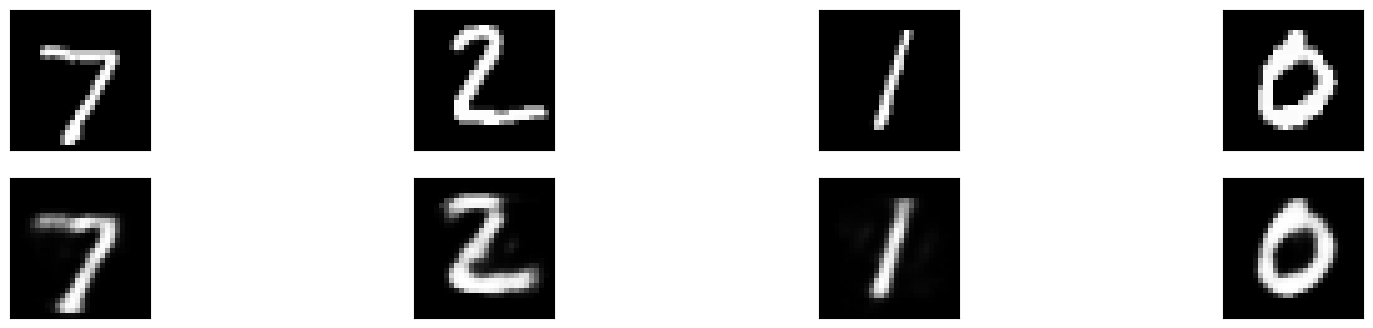

In [111]:
import matplotlib.pyplot as plt

n = 4  # how many digits we will display
plt.figure(figsize=(20, 4))
for i in range(n):
    # display original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # display reconstruction
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


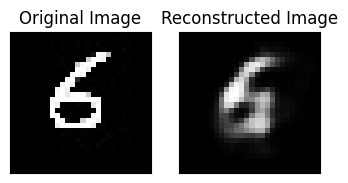

In [116]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt


img_path = 'my_six.jpg'


# Target size should be 28x28 pixels for MNIST-like input
img = image.load_img(img_path, target_size=(28, 28), color_mode='grayscale')

img_array = image.img_to_array(img)
img_array = img_array.astype('float32') / 255.

img_flat = img_array.reshape(1, 784)

encoded_img = encoder.predict(img_flat)
decoded_img = decoder.predict(encoded_img)

plt.figure(figsize=(4, 4))

# Original Image
ax = plt.subplot(1, 2, 1)
plt.imshow(img_array.reshape(28, 28), cmap='gray')
plt.title('Original Image')
ax.get_xaxis().set_visible(False)
ax.get_yaxis().set_visible(False)

# Reconstructed Image
ax = plt.subplot(1, 2, 2)
plt.imshow(decoded_img.reshape(28, 28), cmap='gray')
plt.title('Reconstructed Image')
ax.get_xaxis().set_visible(False)
ax.get_yaxis().set_visible(False)

plt.show()